In [1]:
pip install ipynb

Note: you may need to restart the kernel to use updated packages.


In [2]:
import nbimporter  # type: ignore

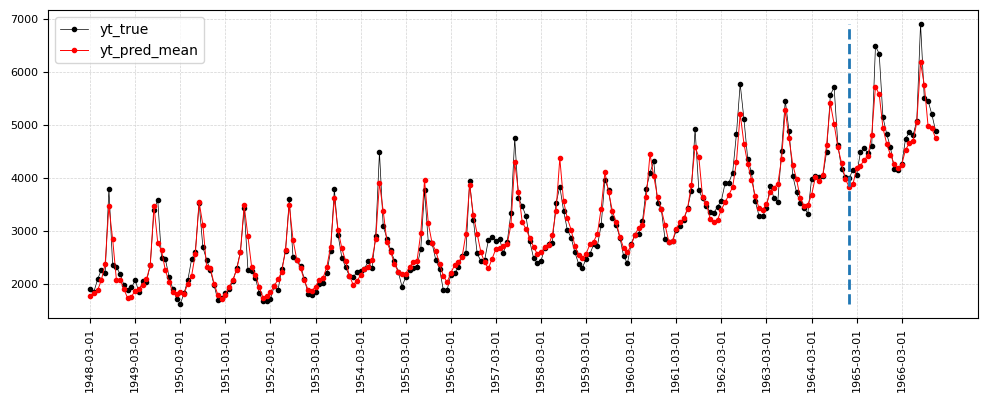

In [5]:
from ipynb.fs.full.functions import *



# =============================================================================
#
# Combinación de pronosticos
#
# =============================================================================
import warnings

warnings.filterwarnings("ignore")

#
# Carga de datos
#

import pandas as pd  # type: ignore

#
# Promedio de los pronosticos
#
df_orig = pd.read_csv("../submission/forecasts.csv")
df_dropna = df_orig.dropna()
df_dropna = df_dropna.set_index("date")
df_dropna["yt_pred_mean"] = df_dropna.mean(axis=1)
plot_time_series(df=df_dropna[["yt_true", "yt_pred_mean"]], yt_col="yt_true")




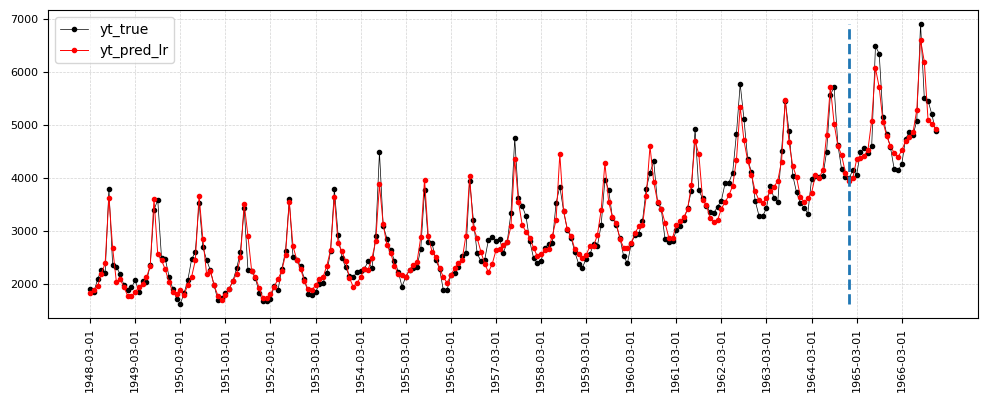

In [9]:

#
# Promedio de los pronosticos
#
from sklearn.linear_model import LinearRegression

model = LinearRegression()
X = df_dropna.drop(columns=["yt_true", "yt_pred_mean"])
y = df_dropna["yt_true"]
model.fit(X, y)
df_dropna["yt_pred_lr"] = model.predict(X)
plot_time_series(df=df_dropna[["yt_true", "yt_pred_lr"]], yt_col="yt_true")

